In [84]:
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

import numpy as np
import gdown
import torch

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import sys
import os

path = '/content/drive/My Drive/MOR/Assignment 2'

if path not in sys.path:
    sys.path.append(path)


Mounted at /content/drive


In [85]:
# FOM discretization
mesh = fe.unitsquaremesh(40, 40)
Vh = fe.space(mesh, 'CG', 1, vector_valued = True)
clc()
download_data = False
if download_data:
  # Dataset (parameters and FOM simulations)
  gdown.download(id = "1XYPnIpVVc9jkd7LwMhC-FYoV2RTnTK8L", output = "floor.npz")
  clc()
  data = np.load("floor.npz")
else:
  data = np.load(os.path.join(path, 'floor.npz'))

mu, u = dv.tensor(data['mu'], data['u'])



Exception ignored in: <function NpzFile.__del__ at 0x7c44fbf86ca0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
OSError: [Errno 107] Transport endpoint is not connected


In [86]:
def animated_warp(u, Vh):
  from dlroms.gifs import save as savegif
  rnd = np.random.randint(50000)
  def drawframe(i):
    plt.figure(figsize = (4, 4))
    fe.plot(u[i], Vh, axis = [-0.25, 1.25, -0.25, 1.25], warp = True)
    plt.title("t = %.2f" % (i*0.02))
    plt.axis("off")
  savegif(drawframe, len(u), "temp%d-gif" % rnd)
  from PIL import Image, ImageSequence
  path = "temp%d-gif.gif" % rnd
  with Image.open(path) as im:
    frames = [frame.copy() for frame in ImageSequence.Iterator(im)]
    frames[0].save(path, save_all=True, append_images=frames[1:], loop=0, duration=im.info.get('duration', 100))
  from IPython.display import Image, display
  display(Image("temp%d-gif.gif" % rnd))
  from os import remove
  remove("temp%d-gif.gif" % rnd)

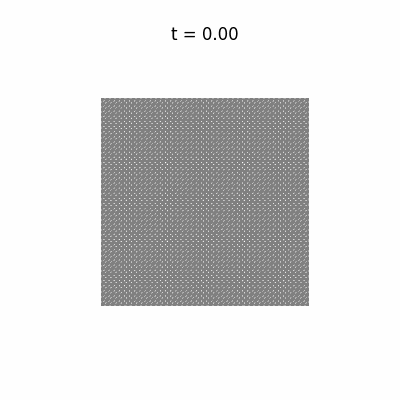

In [87]:
# First simulation in the dataset
animated_warp(u[0], Vh)

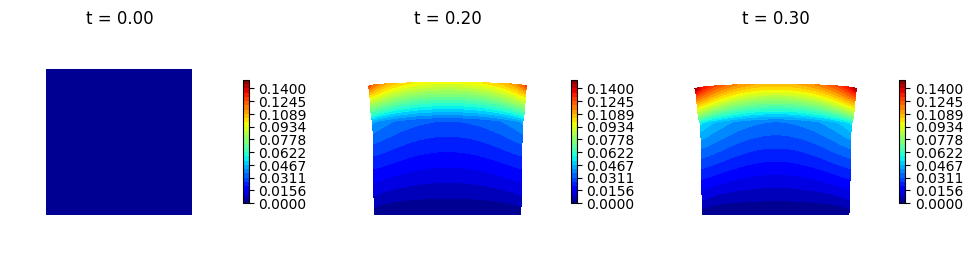

In [88]:
which = 1 # First simulation

ns, nt, nh = u.shape
t = list(np.linspace(0, 1, nt))


umod = u[which].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()
plt.figure(figsize = (12, 4))
for i, ti in enumerate([0, 10, 15]):
  plt.subplot(1, 3, i+1)
  warped_mesh = fe.warpmesh(u[which, ti], Vh)
  delta = mu[which].item()
  WVh = fe.space(warped_mesh, 'CG', 1)

  fe.plot(umod[ti], WVh, levels = 30, vmin = umod.min(), vmax = umod.max(), colorbar = True, shrink = 0.4)
  plt.axis([-0.25, 1.25, -0.25, 1.25])
  plt.title("t = %.2f" % t[ti])
  plt.axis("off")

In [89]:
# Division in train and test
p = mu.shape[-1]
print("Trajectories:\t%d." % ns) # ns = 100
print("Timesteps:\t%d." % nt) # nt = 51
print("FOM dimension:\t%d." % nh) # nh = 3362
print("Parameters:\t%d." % p) # p = 1
mut = dv.zeros(ns, nt, p+1)
times = dv.tensor(np.linspace(0, 1, nt))
for i in range(ns):
    mut[i,:,0] = mu[i]
    mut[i,:,1] = times

ntrain = 75*nt;
u = u.reshape(-1, nh)
mut = mut.reshape(-1, p+1)


Trajectories:	100.
Timesteps:	51.
FOM dimension:	3362.
Parameters:	1.


In [90]:
l2 = L2(Vh)
l2.cuda()
clc()

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, nt).sum(axis = -1)/l2(utrue).reshape(-1, nt).sum(axis = -1)).mean()

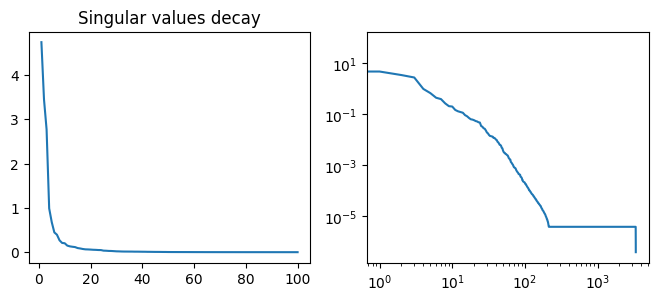

In [91]:
# POD
# Preliminary check to see if we actually need autoencoders!
from scipy.linalg import svd
import matplotlib.pyplot as plt

X, s, _ = svd(u[:ntrain].T.cpu().numpy(), full_matrices = False)
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1)
plt.plot(1+np.arange(100), s[1:101])
plt.title("Singular values decay")
plt.subplot(1, 2, 2)
plt.loglog(s)
plt.show()

In [92]:
n_r = 50
V_dl = X[:,:n_r]
V_dl=dv.tensor(V_dl)
u_r = u @ V_dl




In [121]:
from torch.optim import Adam

rho_e = lambda x: relu(x) -10*relu(-x)
rho_d = lambda x: relu(x) -0.1*relu(-x)
latent = 5
train = False

encoder = Dense(n_r, 40, rho_e) + Dense(40, 30, rho_e) + Dense(30, 10, rho_d) + Dense(10, latent, rho_e)
decoder = Dense(latent, 10, rho_d) + Dense(10, 20, rho_d)+ Dense(20, 30, rho_d) + Dense(30, 40, rho_d) + Dense(40, n_r, activation = None)
autoencoder = DFNN(encoder + decoder)

autoencoder.He()
autoencoder.cuda()

if train:
  autoencoder.train(u_r, u_r, loss = mse(euclidean), ntrain = ntrain, epochs = 250)
  autoencoder.train(u_r, u_r, ntrain = ntrain, loss = mse(euclidean), epochs = 200, optim = Adam, lr = 1e-5, batchsize = 64)

  autoencoder.freeze()
  autoencoder.save(os.path.join(path, 'Weights_POD_DL_ROM'))
else:
  autoencoder.load(os.path.join(path, 'Weights_POD_DL_ROM'))
  autoencoder.freeze()



In [108]:
# from torch.optim import Adam
# rho_e = lambda x: relu(x) -10*relu(-x)
# rho_d = lambda x: relu(x) -0.1*relu(-x)
# latent = 5
# train = False

# encoder = Dense(nh, 100, rho_e) + Dense(100, 50, rho_e) + Dense(50, latent, rho_e)
# decoder = Dense(latent, 30, rho_d) + Dense(30, 50, rho_d) + Dense(50, 100, rho_d) + Dense(100, nh, activation = None)
# autoencoder = DFNN(encoder + decoder)

# autoencoder.He()
# autoencoder.cuda()

# if train:
#   autoencoder.train(u, u, ntrain = ntrain, epochs = 70, loss = mse(l2), error = error, notation = '%')
#   autoencoder.train(u, u, ntrain = ntrain, epochs = 200, loss = mse(l2), optim = Adam, lr = 1e-5, batchsize = 64, error = error, notation = '%')
#   autoencoder.train(u, u, ntrain = ntrain, epochs = 400, loss = mse(l2), optim = Adam, lr = 1e-6, batchsize = 64, error = error, notation = '%')

#   autoencoder.freeze()
#   autoencoder.save(os.path.join(path, 'Weights_DL_ROM'))
# else:
#   autoencoder.load(os.path.join(path, 'Weights_DL_ROM'))
#   autoencoder.freeze()



In [122]:
from dlroms.dnns import Matrix
full_encoder = Matrix(V_dl.T) + encoder
full_decoder = decoder + Matrix(V_dl)
ae = full_encoder + full_decoder

In [123]:
print("Autoencoder MRE: %s" % num2p(error(u[ntrain:], ae(u[ntrain:]))))

Autoencoder MRE: 1.87%


In [128]:

print("POD MRE: %s" % num2p(error(u[ntrain:], u[ntrain:] @ V_dl @ V_dl.T)))

POD MRE: 0.03%


In [137]:
nu = full_encoder(u)
train2 = False

phi = DFNN(Dense(p+1, 30, gelu) + Dense(30, 50, gelu) + Dense(50, 100, gelu) + Dense(100, 50, gelu) + Dense(50, 30, gelu) + Dense(30, latent, activation = None))
phi.He()
phi.cuda()


if train2:
  phi.unfreeze()
  phi.train(mut, nu, ntrain = ntrain, epochs = 350, loss = mse(euclidean), optim = torch.optim.LBFGS)
  phi.freeze()
  phi.save(os.path.join(path, 'Weights_POD_DL_ROM_2'))
else:
  phi.unfreeze()
  phi.load(os.path.join(path, 'Weights_POD_DL_ROM_2'))
  phi.freeze()

		Train		Test
Epoch 350:	5.57e-01	7.78e-01.

>> ETA: 0.27s.

Training complete. Elapsed time: 1 minutes 35.43 seconds.


In [150]:
dlrom = lambda mt: full_decoder(phi(mt))
num2p(error(u[ntrain:], dlrom(mut[ntrain:])))

'2.80%'

In [101]:
from time import perf_counter
t0 = perf_counter()
dlrom(mut[0])
t1 = perf_counter()
dtROM = t1-t0

print("POD-NN solver:\t1 call = %.2f ms" % (1000*dtROM))

speedup = 8.11/dtROM

print("FOM solver time = %.0f x ROM solver time" % speedup)

POD-NN solver:	1 call = 1.58 ms
FOM solver time = 5148 x ROM solver time


In [102]:
nsamples = 1001
mu2 = dv.tensor(np.linspace(0.5,0.9,nsamples))
mut2 = dv.zeros(nsamples, nt, p+1)
for i in range(nsamples):
    mut2[i,:,0] = mu2[i]
    mut2[i,:,1] = times
u2 = dlrom(mut2)
J_rom = dv.zeros(nsamples,1)
J_fom_tr = dv.zeros(75,1)
J_fom_te = dv.zeros(25,1)
u_tr = u[:ntrain].reshape(75,-1)
u_te = u[ntrain:].reshape(25,-1)
mu_tr = mu[:round(ntrain/nt)]
mu_te = mu[round(ntrain/nt):]
for i in range(nsamples):
    J_rom[i] = torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())
    if i < 75:
      J_fom_tr[i] = torch.max(u_tr[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())
    if i < 25:
      J_fom_te[i] = torch.max(u_te[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt())



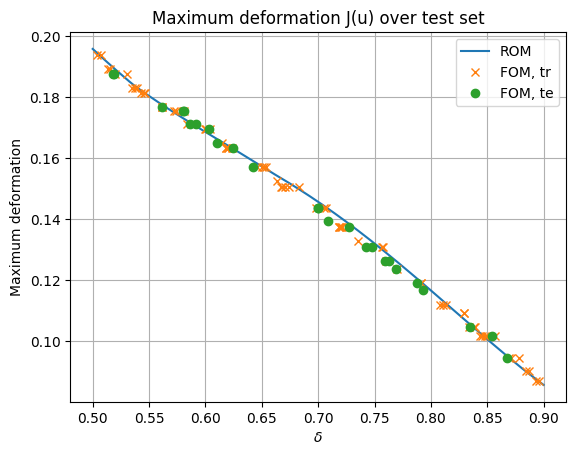

In [103]:
plt.figure()
plt.plot(mu2.cpu().numpy(),J_rom.cpu().detach().numpy(), label='ROM')
plt.plot(mu_tr.cpu().numpy(),J_fom_tr.detach().cpu().numpy(), 'x', label='FOM, tr')
plt.plot(mu_te.cpu().numpy(),J_fom_te.detach().cpu().numpy(), 'o', label='FOM, te')
plt.title('Maximum deformation J(u) over test set')
plt.legend()
plt.xlabel('$\delta$')
plt.ylabel('Maximum deformation')
plt.grid(True)
plt.show()

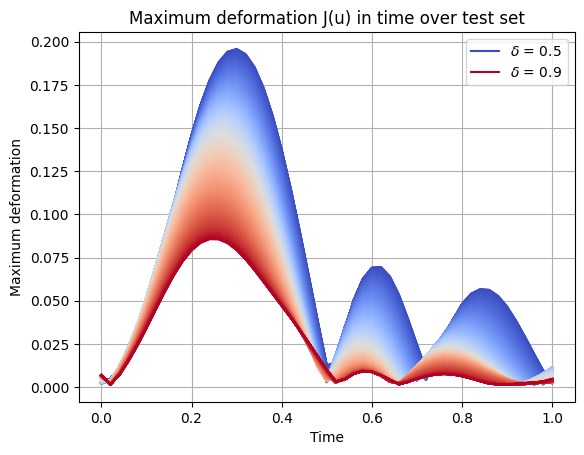

In [104]:
plt.figure()
cmap = plt.cm.coolwarm  # blue to red
for i in range(nsamples):
    color = cmap(i / (nsamples - 1))  # normalized between 0 and 1
    if i == 0:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color, label='$\delta$ = 0.5')
    elif i == nsamples-1:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color, label='$\delta$ = 0.9')
    else:
      plt.plot(times.cpu().numpy(), torch.max(u2[i].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt(), dim = -1)[0][:].detach().cpu().numpy(), color=color)
plt.legend()
plt.title('Maximum deformation J(u) in time over test set')
plt.xlabel('Time')
plt.ylabel('Maximum deformation')
plt.grid(True)
plt.show()

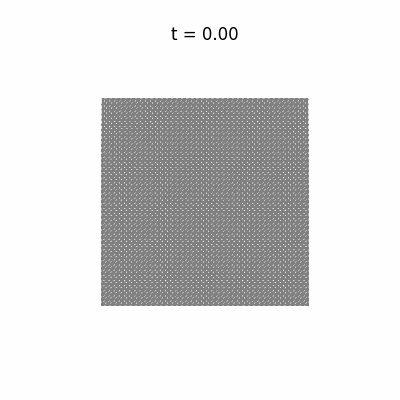

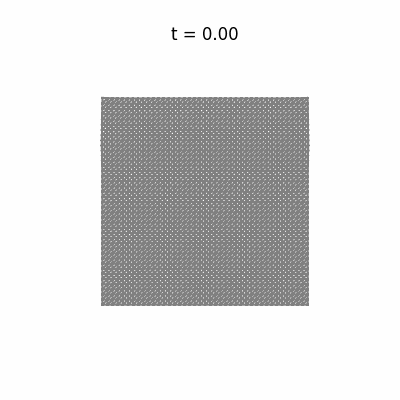

In [105]:
animated_warp(u2[0], Vh)
animated_warp(u2[-1], Vh)



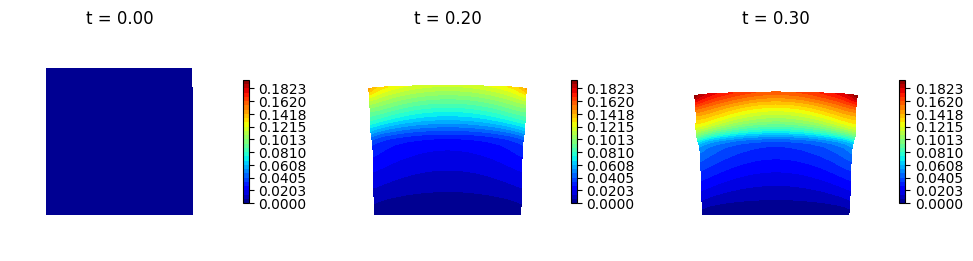

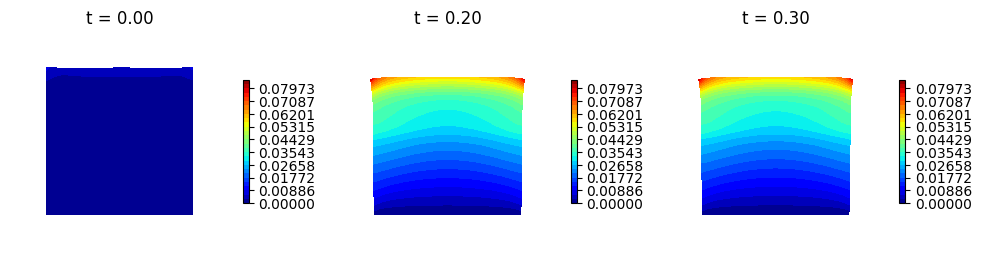

In [106]:
which = 0 # First simulation

umod = u2[which].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()
plt.figure(figsize = (12, 4))
for i, ti in enumerate([0, 10, 15]):
  plt.subplot(1, 3, i+1)
  warped_mesh = fe.warpmesh(u2[which, ti], Vh)
  delta = mu[which].item()
  WVh = fe.space(warped_mesh, 'CG', 1)

  fe.plot(umod[ti], WVh, levels = 30, vmin = umod.min(), vmax = umod.max(), colorbar = True, shrink = 0.4)
  plt.axis([-0.25, 1.25, -0.25, 1.25])
  plt.title("t = %.2f" % t[ti])
  plt.axis("off")

which = -1 # First simulation

umod = u2[which].reshape(nt, -1, 2).pow(2).sum(axis = -1).sqrt()
plt.figure(figsize = (12, 4))
for i, ti in enumerate([0, 10, 15]):
  plt.subplot(1, 3, i+1)
  warped_mesh = fe.warpmesh(u2[which, ti], Vh)
  delta = mu[which].item()
  WVh = fe.space(warped_mesh, 'CG', 1)

  fe.plot(umod[ti], WVh, levels = 30, vmin = umod.min(), vmax = umod.max(), colorbar = True, shrink = 0.4)
  plt.axis([-0.25, 1.25, -0.25, 1.25])
  plt.title("t = %.2f" % t[ti])
  plt.axis("off")